# 20.3 · Evaluation, consent and failure cases

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain evaluation, consent and failure cases using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[02 · Mathematics for Computer Vision](../../02-mathematics-for-computer-vision/README.md), [19 · Face Detection](../../19-face-detection/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Recognition compares representations to decide whether two observations may share an identity. Verification is a one-to-one comparison; identification searches a gallery. The educational lab uses synthetic vectors and anonymous labels so the decision mechanics can be learned without collecting biometric data.

## 2. Intuition

Evaluate false matches, false nonmatches and uncertainty across relevant acquisition conditions. A gallery’s size changes the chance of accidental nearest neighbors. Use informed consent, access control and retention limits for any real biometric extension. Do not infer protected attributes or suitability from an embedding.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 20
LESSON = 2
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
s(a,b)=\frac{a^Tb}{\lVert a\rVert\lVert b\rVert}
$$

a and b are nonzero embedding vectors and s is cosine similarity. For a=[1,0] and b=[1,1], similarity is 1/√2, about 0.707. A threshold is a deployment choice, not a universal constant.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
a, b = np.array([1.0, 0.0]), np.array([1.0, 1.0])
score = a @ b / (np.linalg.norm(a) * np.linalg.norm(b))
assert np.isclose(score, 1 / np.sqrt(2))
print(score)

0.7071067811865475


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

Generated cluster prototypes create anonymous identities. PCA and nearest-prototype comparison demonstrate distance and rejection; they do not constitute a pretrained human-face recognition system.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def recognition(lesson, seed, amount):
    rng = np.random.default_rng(seed)
    base = rng.normal(0, 1, (4, 64))
    train = []
    labels = []
    for identity in range(4):
        for _ in range(6):
            train.append(base[identity] + rng.normal(0, 0.15, 64))
            labels.append(identity)
    train = np.array(train)
    pca = PCA(n_components=8).fit(train)
    embeddings = pca.transform(train)
    centroids = np.array([embeddings[np.array(labels) == i].mean(0) for i in range(4)])
    query = base[1] + rng.normal(0, 0.2 * amount, 64)
    query_embedding = pca.transform(query[None])[0]
    distances = np.linalg.norm(centroids - query_embedding, axis=1)
    threshold = 2.0
    return Result(
        "20 · Embeddings, PCA and verification thresholds",
        {
            "Synthetic prototype 1": base[1].reshape(8, 8),
            "Perturbed query": query.reshape(8, 8),
            "PCA basis vector": pca.components_[0].reshape(8, 8),
        },
        curves={"Distance to each synthetic identity": distances},
        metrics={
            "nearest_synthetic_identity": int(distances.argmin()),
            "verified_with_threshold": bool(distances[1] < threshold),
            "threshold": threshold,
        },
        notes="Synthetic vectors demonstrate verification mathematics. They are not a face-recognition model or evidence of biometric accuracy.",
    )

{
  "nearest_synthetic_identity": 1,
  "verified_with_threshold": true,
  "threshold": 2.0
}
Synthetic vectors demonstrate verification mathematics. They are not a face-recognition model or evidence of biometric accuracy.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import softmax

display(Code(inspect.getsource(softmax), language="python"))

def softmax(values, axis=-1):
    values = np.asarray(values, float)
    exp = np.exp(values - values.max(axis=axis, keepdims=True))
    return exp / exp.sum(axis=axis, keepdims=True)

## 8. Experiment

Add unknown synthetic identities and sweep the threshold. Plot false acceptance and false rejection rather than only closed-set accuracy.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "nearest_synthetic_identity": 1,
    "verified_with_threshold": true,
    "threshold": 2.0
  },
  "second_seed": {
    "nearest_synthetic_identity": 1,
    "verified_with_threshold": true,
    "threshold": 2.0
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

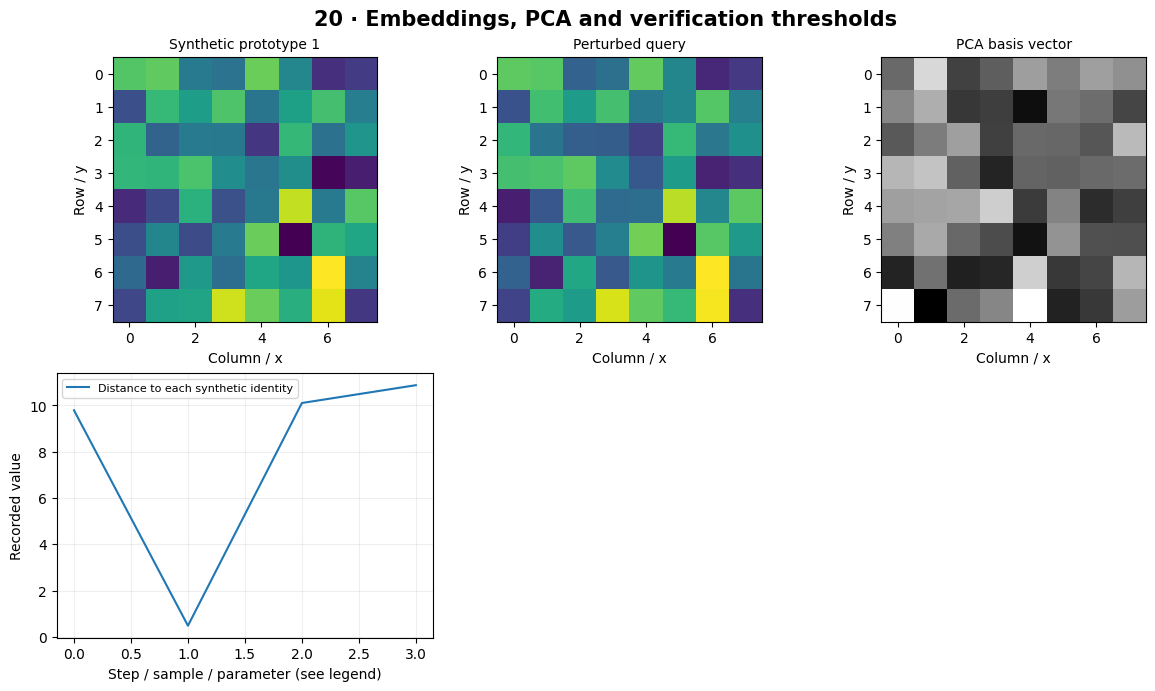

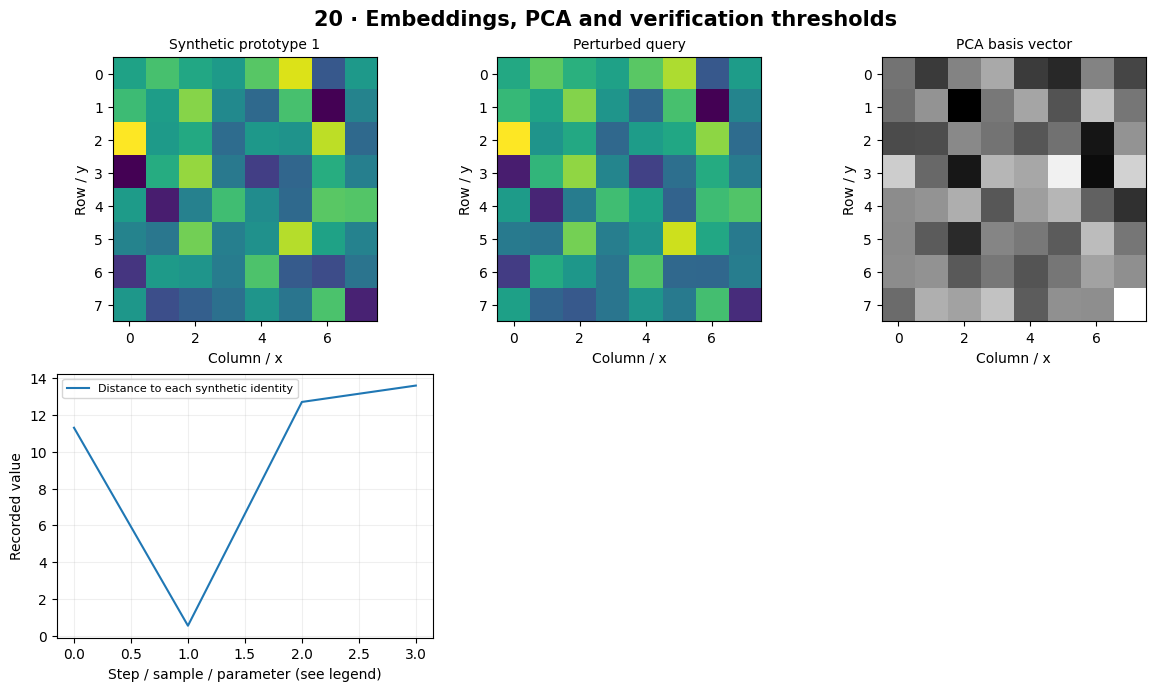

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Local Opt-in Verification Lab**. Study small consented verification experiments with error analysis. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Selecting the threshold on the test set leaks evaluation information. Good synthetic cluster separation is not evidence of biometric performance.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Add unknown synthetic identities and sweep the threshold. Plot false acceptance and false rejection rather than only closed-set accuracy.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build an anonymous embedding verifier with an explicit unknown outcome and a validation-only threshold selection report.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Evaluate false matches, false nonmatches and uncertainty across relevant acquisition conditions. A gallery’s size changes the chance of accidental nearest neighbors. Use informed consent, access control and retention limits for any real biometric extension. Do not infer protected attributes or suitability from an embedding.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

[21 · OCR](../../21-ocr/README.md)

[Primary reference](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)